In [ ]:
import zipfile

with zipfile.ZipFile('/content/bank+marketing.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/bank_marketing')

In [ ]:
import os

os.listdir('/content/bank_marketing')

['bank-additional.zip', 'bank.zip']

In [ ]:
import zipfile

with zipfile.ZipFile('/content/bank_marketing/bank.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/bank_data')

In [ ]:
import os

os.listdir('/content/bank_data')

['bank-names.txt', 'bank-full.csv', 'bank.csv']

In [ ]:
import pandas as pd

df = pd.read_csv('/content/bank_data/bank-full.csv', sep=';')

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df.shape

(45211, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


In [ ]:
X = df.drop('y', axis=1)
y = df['y']

In [ ]:
print(X.shape)
print(y.shape)

(45211, 16)
(45211,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(36168, 16)
(9043, 16)
(36168,)
(9043,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

Observation
The Decision Tree learned patterns from the training data.
We used:
Entropy as the splitting criterion.
Max depth = 5 to avoid overfitting.

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8848833351763795


Observation
The model correctly predicted about 88.5% of the test samples.
This is a good accuracy score for the Bank Marketing dataset.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[7749  203]
 [ 838  253]]


Observation
The model is very good at identifying customers who will not subscribe.
It correctly classified 7749 non-subscribers.
However, it missed 838 actual subscribers, which is relatively high.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.97      0.94      7952
           1       0.55      0.23      0.33      1091

    accuracy                           0.88      9043
   macro avg       0.73      0.60      0.63      9043
weighted avg       0.86      0.88      0.86      9043



The Decision Tree achieves 88.49% accuracy.
Performance for the majority class ("No") is excellent.
Performance for the minority class ("Yes") is weaker because the dataset is imbalanced.
Overall, the model is useful for predicting customer behavior but could be improved using balancing techniques.

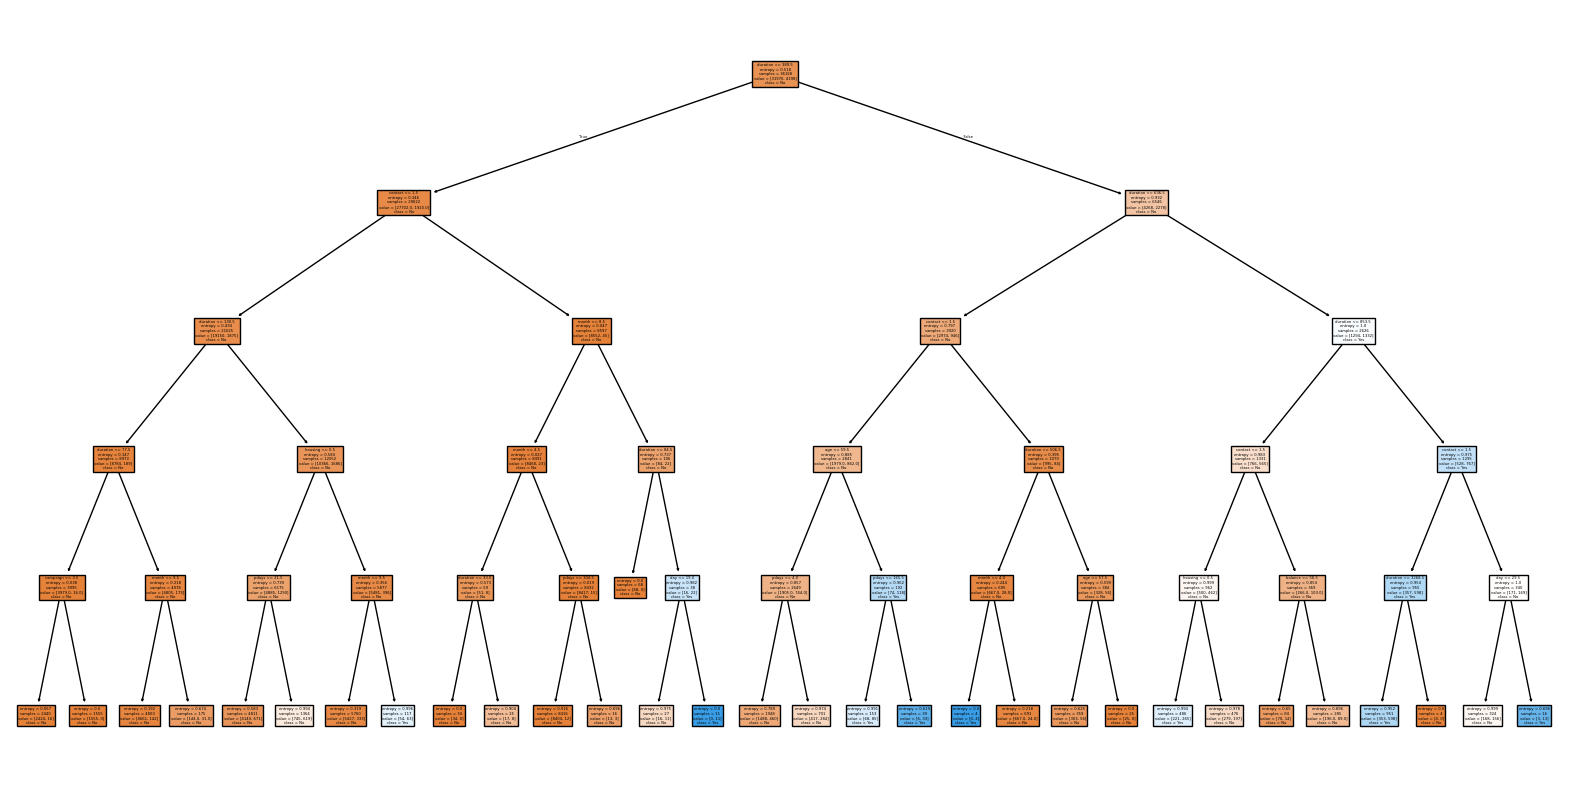

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True
)

plt.show()

Observation
The root node is based on duration, meaning it is the most influential feature for making predictions.
Orange nodes mostly represent "No" subscriptions.
Blue nodes represent "Yes" subscriptions.
As we move down the tree, the model uses additional features to make more specific decisions.

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

importance.head(10)

,Feature,Importance
11,duration,0.620080
8,contact,0.160752
13,pdays,0.080569
6,housing,0.065447
10,month,0.056366
0,age,0.011288
9,day,0.002701
12,campaign,0.001907
5,balance,0.000890
7,loan,0.000000


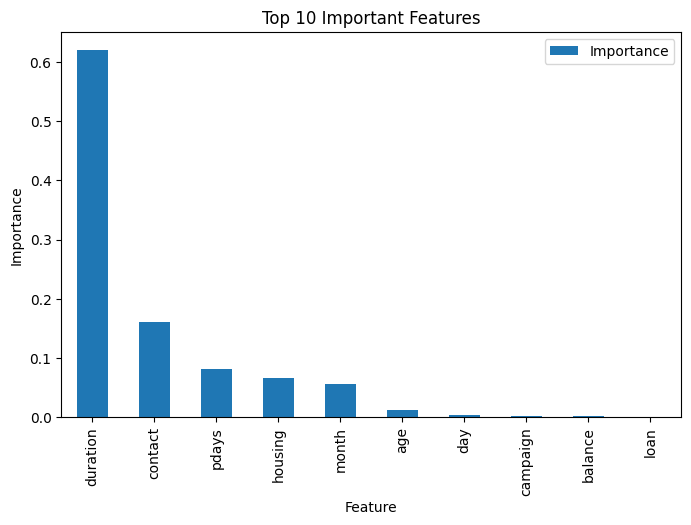

In [ ]:
importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(8,5)
)

plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()

Final Observation:

The Bank Marketing dataset contains 45,211 customer records and 17 attributes.
No missing values were found in the dataset.
Categorical variables were encoded into numerical values.
The dataset was split into 80% training and 20% testing data.
A Decision Tree Classifier was trained using entropy as the splitting criterion.
The model achieved 88.49% accuracy.
The model performed very well in identifying customers who would not subscribe.
The most influential feature was duration.
Final Project Conclusion


Conclusion:
A Decision Tree Classifier was successfully developed to predict whether a customer would subscribe to a bank term deposit. After preprocessing and training, the model achieved an accuracy of 88.49%. Feature importance analysis revealed that duration was the most significant predictor. Although the model performed well overall, its performance on the minority class ("Yes") was lower due to class imbalance. Overall, the Decision Tree proved effective for customer subscription prediction.